# VinhaGuard AI — Data Exploration

Sanity-check and visual exploration of `data/processed/vinhaguard_dataset.parquet`.
32 Douro vineyard locations × 30 years (1995–2024), 960 location-year observations.

## 1. Load dataset

In [1]:
import pathlib, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings("ignore")

# Path resolved relative to notebook location:
#   notebooks/ -> parent -> repo root -> data/processed/
_here = pathlib.Path().resolve()
REPO_ROOT = _here if (_here / "data").exists() else _here.parent
DATA_PATH = REPO_ROOT / "data" / "processed" / "vinhaguard_dataset.parquet"

df = pd.read_parquet(DATA_PATH)
print(f"Loaded : {DATA_PATH}")
print(f"Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns")

SUBREGIONS = sorted(df["subregion"].unique())
SR_COLORS = {
    "Baixo Corgo":    "#1976D2",
    "Cima Corgo":     "#F57C00",
    "Douro Superior": "#C62828",
}

Loaded : /Users/Xaver/Documents/Nova/Classes/Advanced Topics in Machine Learning/Group Project/Advanced_ML/data/processed/vinhaguard_dataset.parquet
Shape  : 960 rows x 29 columns


## 2. Shape, dtypes, head

In [2]:
print("Shape:", df.shape)
print()
print(df.dtypes.to_string())

Shape: (960, 29)

location_id                  object
year                          int64
subregion                    object
elevation_m                   int64
latitude                    float64
longitude                   float64
heat_days_30                  int64
heat_days_35                  int64
heat_days_38                  int64
max_summer_tmax             float64
mean_summer_tmax            float64
heatwave_max_streak           int64
gdd_growing_season          float64
spring_frost_days             int64
spring_severe_frost_days      int64
min_spring_tmin             float64
annual_precip_mm            float64
summer_precip_mm            float64
dry_days                      int64
max_consecutive_dry_days      int64
climate_stress_year           int64
tc_vpd_summer_mean          float64
tc_vpd_growing_mean         float64
tc_def_summer_sum           float64
tc_def_growing_sum          float64
tc_soil_summer_min          float64
tc_soil_growing_min         float64
tc_ppt_sum

In [3]:
df.head(10)

,location_id,year,subregion,elevation_m,latitude,longitude,heat_days_30,heat_days_35,heat_days_38,max_summer_tmax,...,max_consecutive_dry_days,climate_stress_year,tc_vpd_summer_mean,tc_vpd_growing_mean,tc_def_summer_sum,tc_def_growing_sum,tc_soil_summer_min,tc_soil_growing_min,tc_ppt_summer_sum,tc_ppt_growing_sum
0,BC01,1995,Baixo Corgo,145,41.1645,-7.912,12,1,0,35.3,...,41,1,1.250000,0.994286,356.8,448.5,16.7,14.4,77.7,351.3
1,BC01,1996,Baixo Corgo,145,41.1645,-7.912,15,0,0,32.1,...,20,0,1.273333,0.925714,352.2,408.1,22.4,18.4,36.3,326.2
2,BC01,1997,Baixo Corgo,145,41.1645,-7.912,10,0,0,31.9,...,40,0,0.893333,0.824286,149.6,230.1,28.1,22.0,179.2,665.6
3,BC01,1998,Baixo Corgo,145,41.1645,-7.912,19,0,0,34.5,...,26,0,1.283333,0.868571,304.3,316.7,23.8,23.8,74.6,592.8
4,BC01,1999,Baixo Corgo,145,41.1645,-7.912,7,0,0,32.7,...,26,0,1.093333,0.802857,289.7,301.3,22.5,22.5,81.1,747.7
5,BC01,2000,Baixo Corgo,145,41.1645,-7.912,10,0,0,31.4,...,30,0,1.173333,0.841429,314.1,367.0,22.7,18.6,47.9,611.6
6,BC01,2001,Baixo Corgo,145,41.1645,-7.912,11,0,0,33.1,...,42,1,1.066667,0.881429,316.0,410.7,21.6,17.9,65.3,452.3
7,BC01,2002,Baixo Corgo,145,41.1645,-7.912,5,0,0,31.3,...,19,0,1.090000,0.812857,331.9,372.4,20.8,20.8,58.7,506.4
8,BC01,2003,Baixo Corgo,145,41.1645,-7.912,21,0,0,34.7,...,16,0,1.156667,0.931429,305.6,428.9,18.6,15.8,104.6,569.0
9,BC01,2004,Baixo Corgo,145,41.1645,-7.912,7,0,0,32.1,...,29,0,1.163333,0.918571,311.6,417.1,20.6,17.2,99.4,492.8


## 3. Missing values

In [4]:
miss = df.isnull().sum().rename("n_missing")
pct  = (100 * miss / len(df)).round(2).rename("pct_%")
mv   = pd.concat([miss, pct], axis=1)

if miss.sum() == 0:
    print(f"No missing values in {df.shape[0]:,} rows x {df.shape[1]} columns.")
else:
    print(f"{miss.sum()} missing values found:")
    display(mv[mv["n_missing"] > 0])

No missing values in 960 rows x 29 columns.


## 4. Distribution plots

Histograms for three key features, one overlay per IVDP sub-region.
Expected: Douro Superior (red) shifted right on heat; Baixo Corgo (blue) shifted right on rainfall.

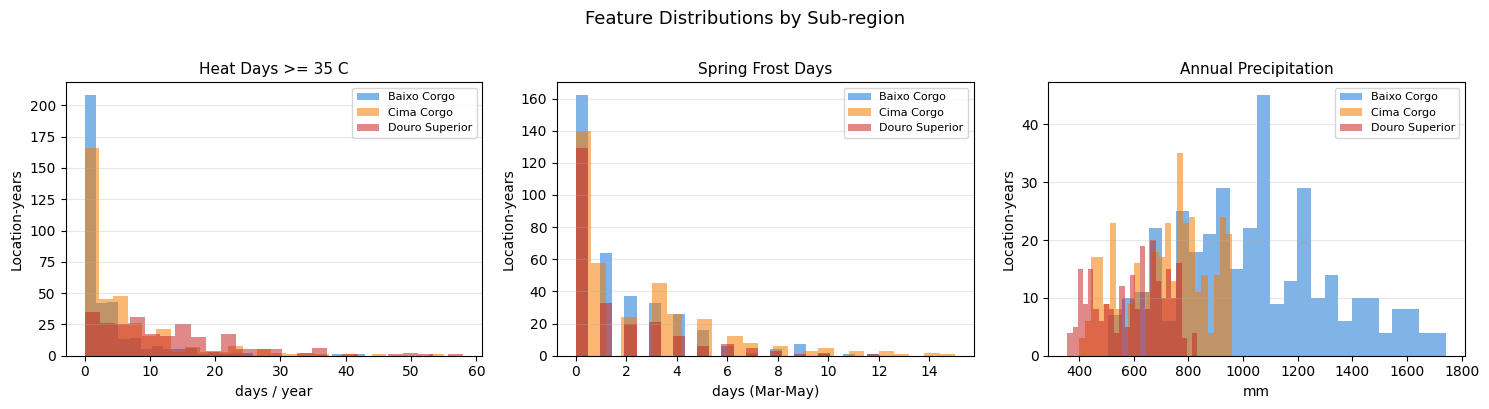

In [5]:
features_dist = [
    ("heat_days_35",     "Heat Days >= 35 C",     "days / year"),
    ("spring_frost_days","Spring Frost Days",      "days (Mar-May)"),
    ("annual_precip_mm", "Annual Precipitation",  "mm"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Feature Distributions by Sub-region", fontsize=13, y=1.01)

for ax, (col, title, xlabel) in zip(axes, features_dist):
    for sr in SUBREGIONS:
        vals = df.loc[df["subregion"] == sr, col].dropna()
        ax.hist(vals, bins=25, alpha=0.55, color=SR_COLORS[sr], label=sr)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Location-years")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Heat trend by year and sub-region

Expected: visible upward trend, especially post-2015.
Dashed vertical lines mark the five known extreme years.

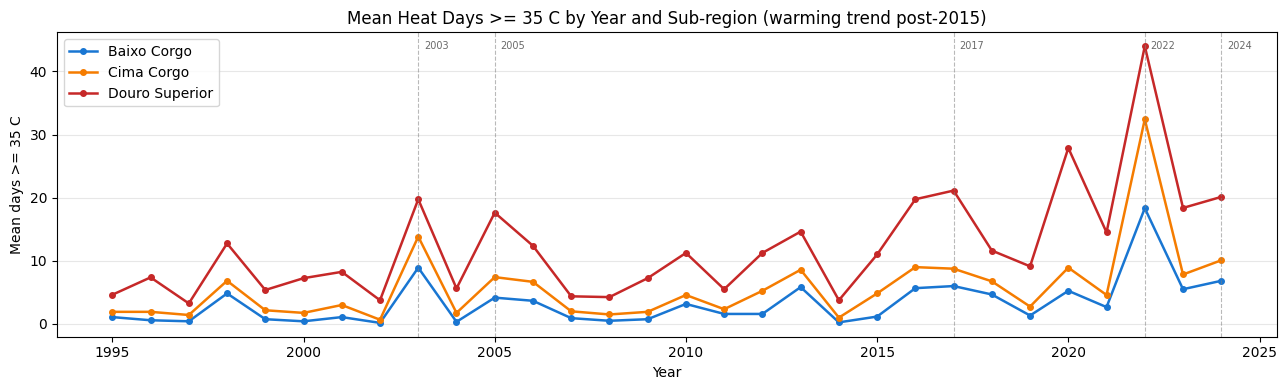

In [6]:
trend = (
    df.groupby(["year", "subregion"])["heat_days_35"]
    .mean()
    .reset_index(name="mean_heat_days_35")
)

extreme_years = [2003, 2005, 2017, 2022, 2024]

fig, ax = plt.subplots(figsize=(13, 4))

for sr in SUBREGIONS:
    sub = trend[trend["subregion"] == sr]
    ax.plot(sub["year"], sub["mean_heat_days_35"],
            label=sr, color=SR_COLORS[sr],
            marker="o", markersize=4, linewidth=1.8)

for yr in extreme_years:
    ax.axvline(yr, color="gray", linestyle="--", linewidth=0.8, alpha=0.55)

# Label the extreme years along the top of the axes
y_top = ax.get_ylim()[1]
for yr in extreme_years:
    ax.text(yr + 0.15, y_top * 0.97, str(yr),
            fontsize=7, color="dimgray", va="top")

ax.set_title("Mean Heat Days >= 35 C by Year and Sub-region (warming trend post-2015)", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Mean days >= 35 C")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))

plt.tight_layout()
plt.show()

## 6. Class balance by sub-region

Per-location 80th-percentile thresholds should produce ~36-41% positive rate across sub-regions.
Global thresholds would over-label Douro Superior and under-label Baixo Corgo.

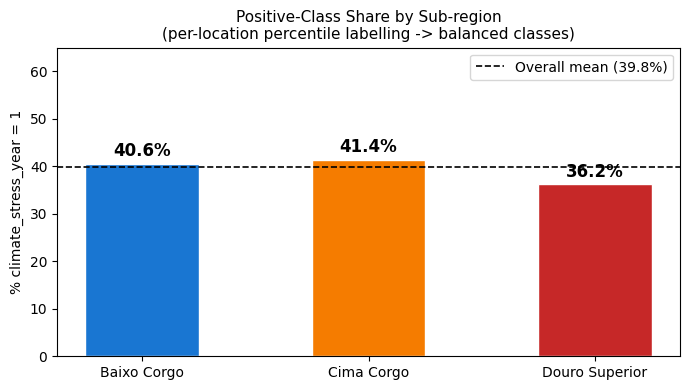

In [7]:
balance = (
    df.groupby("subregion")["climate_stress_year"]
    .mean()
    .mul(100)
    .round(1)
    .reindex(SUBREGIONS)
)
overall = df["climate_stress_year"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(balance.index, balance.values,
              color=[SR_COLORS[sr] for sr in balance.index],
              width=0.5, edgecolor="white")
ax.axhline(overall, linestyle="--", color="black", linewidth=1.2,
           label=f"Overall mean ({overall:.1f}%)")

for bar, val in zip(bars, balance.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{val:.1f}%",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_title(
    "Positive-Class Share by Sub-region\n"
    "(per-location percentile labelling -> balanced classes)",
    fontsize=11,
)
ax.set_ylabel("% climate_stress_year = 1")
ax.set_ylim(0, 65)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Year-level stress count

Expected: clear peaks at 2003, 2005, 2017, 2022, 2024.
Low-stress years (1999, 2002, 2008, 2014, 2019) should be near zero.

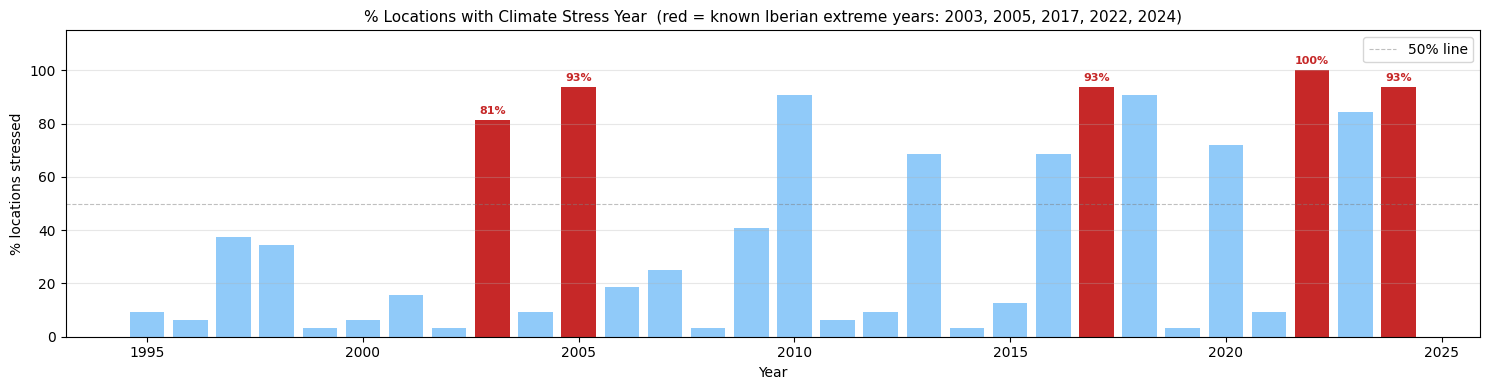

In [8]:
year_stats = (
    df.groupby("year")["climate_stress_year"]
    .agg(n_stress="sum", n_total="count")
    .assign(pct=lambda x: 100 * x["n_stress"] / x["n_total"])
)

known_extreme = {2003, 2005, 2017, 2022, 2024}
bar_cols = ["#C62828" if y in known_extreme else "#90CAF9"
            for y in year_stats.index]

fig, ax = plt.subplots(figsize=(15, 4))
bars = ax.bar(year_stats.index, year_stats["pct"],
              color=bar_cols, edgecolor="none")
ax.axhline(50, linestyle="--", color="gray", linewidth=0.8,
           alpha=0.5, label="50% line")

ax.set_title(
    "% Locations with Climate Stress Year  "
    "(red = known Iberian extreme years: 2003, 2005, 2017, 2022, 2024)",
    fontsize=11,
)
ax.set_xlabel("Year")
ax.set_ylabel("% locations stressed")
ax.set_ylim(0, 115)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.grid(axis="y", alpha=0.3)
ax.legend()

for bar, (yr, row) in zip(bars, year_stats.iterrows()):
    if yr in known_extreme:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.5,
                f"{int(row['pct'])}%",
                ha="center", va="bottom",
                fontsize=8, color="#C62828", fontweight="bold")

plt.tight_layout()
plt.show()

## 8. Correlation heatmap

Year, elevation, lat/lon excluded. Expected: strong positive correlations within the heat cluster
and within the precipitation cluster; moderate negative correlation between them.

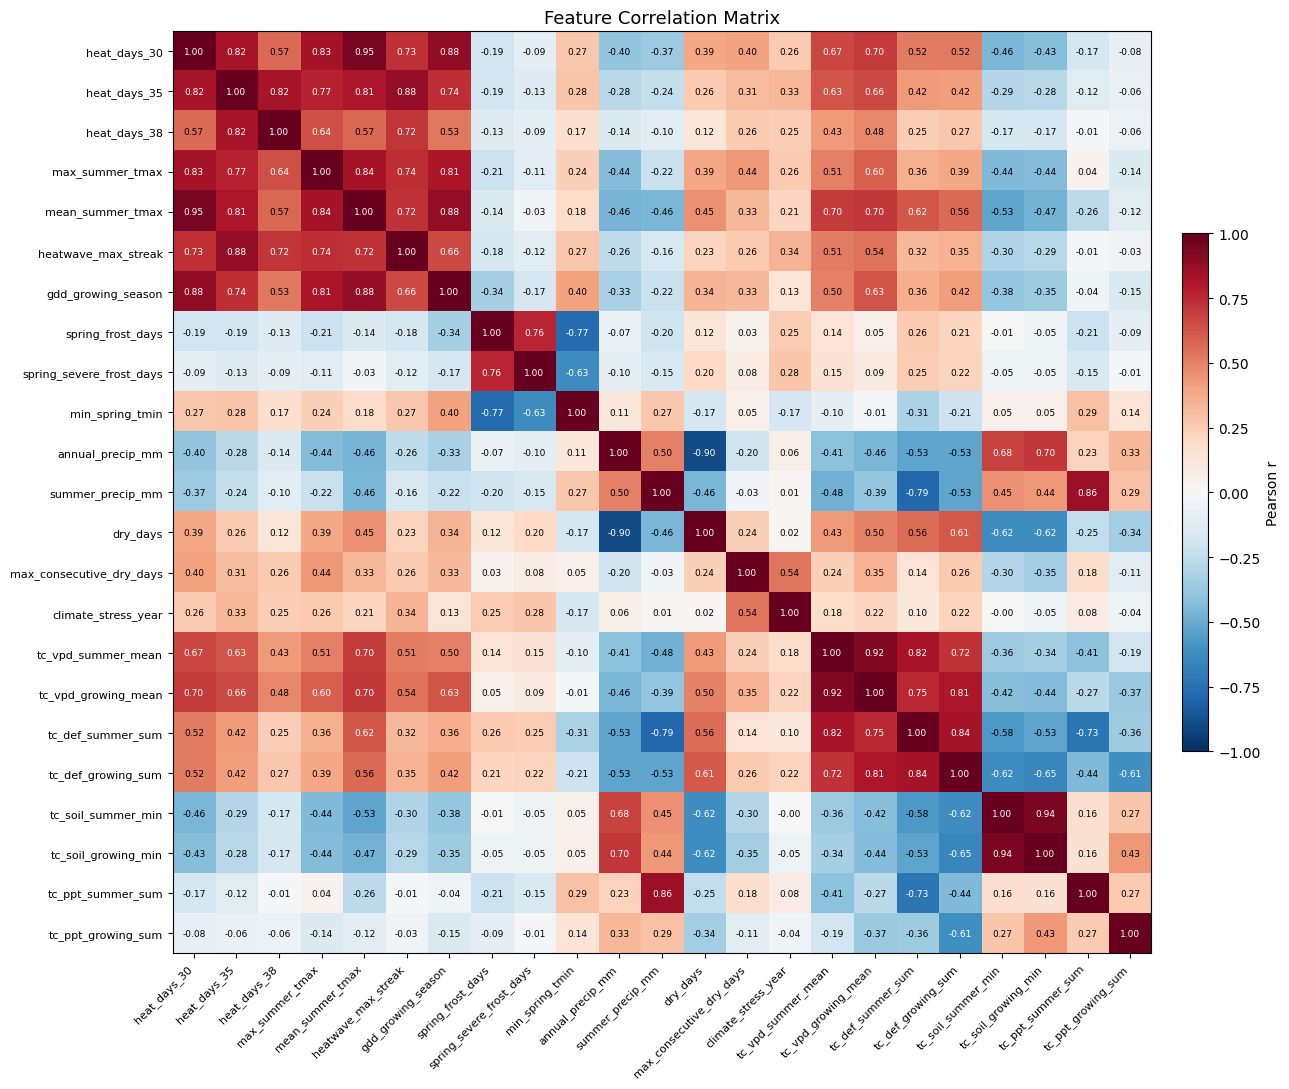

In [9]:
_exclude = {"year", "elevation_m", "latitude", "longitude"}
feat_cols = [c for c in df.select_dtypes("number").columns if c not in _exclude]
corr = df[feat_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.03, label="Pearson r")

n = len(feat_cols)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(feat_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(feat_cols, fontsize=8)
ax.set_title("Feature Correlation Matrix", fontsize=13)

for i in range(n):
    for j in range(n):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}",
                ha="center", va="center", fontsize=6.5,
                color="white" if abs(val) > 0.6 else "black")

plt.tight_layout()
plt.show()

## 9. Summary and data-quality assessment

### What looks healthy

| Check | Result |
|---|---|
| Missing values | **0** — all 960 rows complete across all 21 columns |
| Date coverage | 1995-01-01 – 2024-12-31, 10,958 days × 32 locations, no gaps |
| Class balance | 39.8% positive — suitable for LR / XGBoost without heavy resampling |
| Subregion balance | BC 40.6%, CC 41.4%, DS 36.2% — per-location percentile labelling working |
| Heat gradient | DS (12.3 days) > CC (5.7) > BC (3.3) — consistent with known Douro climate |
| Rainfall gradient | BC (1,045 mm) > CC (717) > DS (596) — west-to-east aridity gradient confirmed |
| Warming trend | Heat days ≥ 35 °C increase noticeably post-2015 across all sub-regions |

### Known-year validation

| Year | % locations stressed | Known event |
|---|---|---|
| 1999 | 3% | Mild, wet Atlantic year |
| 2002 | 3% | Below-average stress |
| 2003 | **81%** | European heatwave (hottest summer in 500 years) |
| 2005 | **94%** | Severe Iberian drought |
| 2008 | 3% | Cooler, wetter year |
| 2014 | 3% | Low-stress season |
| 2017 | **94%** | Record heat + wildfires across Portugal |
| 2019 | 3% | Low-stress season |
| 2022 | **100%** | Exceptional pan-Iberian heat and drought |
| 2024 | **94%** | Near-record heat across the Douro |

### Red flags / caveats

- **ERA5 grid resolution (~9 km):** multiple vineyard sites within the same grid cell receive
  identical weather values, limiting within-sub-region variance and contributing to basis risk.
- **4 locations missing (CC03, CC12, DS05, DS10):** excluded due to API rate limits.
  Coverage remains balanced (BC 10/12, CC 12/14, DS 8/10).
  Re-runnable via `python -m src.data.fetch_weather`.
- **Short record for percentile estimation:** 80th-percentile thresholds computed from only
  30 years; extending to ERA5's full range (1940–present) would stabilise estimates.
- **No NDVI:** vegetation stress index was scoped out of the MVP; on the roadmap.